In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# exps = [
#     "scream_dpxx_DYCOMSrf01_a300_p80",
#     "scream_dpxx_DYCOMSrf01_a9999_p55",
#     "scream_dpxx_DYCOMSrf01_a8000_p55",
#     "scream_dpxx_DYCOMSrf01_a4000_p55",
#     "scream_dpxx_DYCOMSrf01_a1_1",
#     "scream_dpxx_DYCOMSrf01_a30_p80",
#     "scream_dpxx_DYCOMSrf01_a860_p60",
#     "scream_dpxx_DYCOMSrf01_a2000_p55",
#     "scream_dpxx_DYCOMSrf01_a2000_p55_0ps",
#     "scream_dpxx_DYCOMSrf01_a4654_p50",
#     "scream_dpxx_DYCOMSrf01_a1000_p55",
# ]

exps = [
    "scream_dpxx_DYCOMSrf01_a300_p80_0ps",
    "scream_dpxx_DYCOMSrf01_a9999_p55_0ps",
    "scream_dpxx_DYCOMSrf01_a8000_p55_0ps",
    "scream_dpxx_DYCOMSrf01_a4000_p55_0ps",
    "scream_dpxx_DYCOMSrf01_a1_1_0ps",
    "scream_dpxx_DYCOMSrf01_a30_p80_0ps",
    "scream_dpxx_DYCOMSrf01_a860_p60_0ps",
    "scream_dpxx_DYCOMSrf01_a2000_p55_0ps",
    "scream_dpxx_DYCOMSrf01_a4654_p50_0ps",
    "scream_dpxx_DYCOMSrf01_a1000_p55_0ps",
]

In [70]:
data = {}; dfs = {}
for exp in exps:
    exp = exp[:-4]  # remove _0ps
    print(f"Loading {exp}")
    data[exp] = xr.open_mfdataset(f"/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/{exp}/run/{exp}.scream.h.INSTANT.nmins_x5.1999-*.nc")
    data[exp+"_0ps"] = xr.open_mfdataset(f"/pscratch/sd/m/mahf708/dp_screamxx_aero_pert/extra_0ps/{exp}_0ps/run/{exp}_0ps.scream.h.INSTANT.nmins_x5.1999-*.nc")
    dfs[exp] = data[exp][["cdnc_at_cldtop", "cldfrac_liq_at_cldtop", "eff_radius_qc_at_cldtop", "LiqWaterPath", "pbl_height", "precip_liq_surf_mass_flux"]].unify_chunks().to_dataframe()
    dfs[exp+"_0ps"] = data[exp+"_0ps"][["cdnc_at_cldtop", "cldfrac_liq_at_cldtop", "eff_radius_qc_at_cldtop", "LiqWaterPath", "pbl_height", "precip_liq_surf_mass_flux"]].unify_chunks().to_dataframe()
    # expand AeroComCldTop and AeroComCldBot
    # T_mid :
    # 0 (K)
    # cdnc :
    # 4 (#/m3)
    # cldfrac_ice :
    # 2 (nondim)
    # cldfrac_liq :
    # 3 (nondim)
    # cldfrac_tot :
    # 7 (nondim)
    # eff_radius_qc :
    # 5 (micron)
    # eff_radius_qi :
    # 6 (micron)
    # nc :
    # 8 (1/kg)
    # ni :
    # 9 (1/kg)
    # p_mid :
    # 1 (Pa)
    dfs[exp]["acct_T_mid"] = data[exp]["AeroComCldTop"].isel(dim10=0).values.flatten()
    dfs[exp]["acct_cdnc"] = data[exp]["AeroComCldTop"].isel(dim10=4).values.flatten()
    dfs[exp]["acct_cldfrac_ice"] = data[exp]["AeroComCldTop"].isel(dim10=2).values.flatten()
    dfs[exp]["acct_cldfrac_liq"] = data[exp]["AeroComCldTop"].isel(dim10=3).values.flatten()
    dfs[exp]["acct_cldfrac_tot"] = data[exp]["AeroComCldTop"].isel(dim10=7).values.flatten()
    dfs[exp]["acct_eff_radius_qc"] = data[exp]["AeroComCldTop"].isel(dim10=5).values.flatten()
    dfs[exp]["acct_eff_radius_qi"] = data[exp]["AeroComCldTop"].isel(dim10=6).values.flatten()
    dfs[exp]["acct_nc"] = data[exp]["AeroComCldTop"].isel(dim10=8).values.flatten()
    dfs[exp]["acct_ni"] = data[exp]["AeroComCldTop"].isel(dim10=9).values.flatten()
    dfs[exp]["acct_p_mid"] = data[exp]["AeroComCldTop"].isel(dim10=1).values.flatten()
    dfs[exp+"_0ps"]["acct_T_mid"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=0).values.flatten()
    dfs[exp+"_0ps"]["acct_cdnc"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=4).values.flatten()
    dfs[exp+"_0ps"]["acct_cldfrac_ice"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=2).values.flatten()
    dfs[exp+"_0ps"]["acct_cldfrac_liq"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=3).values.flatten()
    dfs[exp+"_0ps"]["acct_cldfrac_tot"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=7).values.flatten()
    dfs[exp+"_0ps"]["acct_eff_radius_qc"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=5).values.flatten()
    dfs[exp+"_0ps"]["acct_eff_radius_qi"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=6).values.flatten()
    dfs[exp+"_0ps"]["acct_nc"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=8).values.flatten()
    dfs[exp+"_0ps"]["acct_ni"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=9).values.flatten()
    dfs[exp+"_0ps"]["acct_p_mid"] = data[exp+"_0ps"]["AeroComCldTop"].isel(dim10=1).values.flatten()


Loading scream_dpxx_DYCOMSrf01_a300_p80
Loading scream_dpxx_DYCOMSrf01_a9999_p55
Loading scream_dpxx_DYCOMSrf01_a8000_p55
Loading scream_dpxx_DYCOMSrf01_a4000_p55
Loading scream_dpxx_DYCOMSrf01_a1_1
Loading scream_dpxx_DYCOMSrf01_a30_p80
Loading scream_dpxx_DYCOMSrf01_a860_p60
Loading scream_dpxx_DYCOMSrf01_a2000_p55
Loading scream_dpxx_DYCOMSrf01_a4654_p50
Loading scream_dpxx_DYCOMSrf01_a1000_p55


In [71]:
for df in dfs.values():
    df["LiqWaterPath"] = 100* df["LiqWaterPath"] / df["cldfrac_liq_at_cldtop"]
    df["cdnc_at_cldtop"] = df["cdnc_at_cldtop"] / df["cldfrac_liq_at_cldtop"] / 1e6

In [72]:
for df_name,df in dfs.items():
    df["exp"] = df_name if "0ps" not in df_name else df_name[:-4]
    if "0ps" in df_name:
        df["Sensitivity"] = "No precipitation suppression"
    else:
        df["Sensitivity"] = "Default"
dfs[exp]

cdnc_at_cldtop  cldfrac_liq_at_cldtop  \
time                ncol                                          
1999-07-11 00:00:00 0                NaN                    NaN   
                    1                NaN                    NaN   
                    2                NaN                    NaN   
                    3                NaN                    NaN   
                    4                NaN                    NaN   
...                                  ...                    ...   
1999-07-11 06:00:00 95         23.820272                    1.0   
                    96         24.812992                    1.0   
                    97         25.105114                    1.0   
                    98         24.789194                    1.0   
                    99         24.952253                    1.0   

                          eff_radius_qc_at_cldtop  LiqWaterPath  pbl_height  \
time                ncol                                                      
1999-07-11 00:00:00 0                         NaN           NaN         NaN   
                    1                         NaN           NaN         NaN   
                    2                         NaN           NaN         NaN   
                    3                         NaN           NaN         NaN   
                    4                         NaN           NaN         NaN   
...                                           ...           ...         ...   
1999-07-11 06:00:00 95                  18.098045     17.820288  492.852051   
                    96                  14.873350      7.269698  795.705200   
                    97                  13.271614      4.512628  770.782104   
                    98                  14.007753     12.991682  716.693848   
                    99                  14.171041      5.906250  776.176453   

                          precip_liq_surf_mass_flux  acct_T_mid   acct_cdnc  \
time                ncol                                                      
1999-07-11 00:00:00 0                           NaN         NaN         NaN   
                    1                           NaN         NaN         NaN   
                    2                           NaN         NaN         NaN   
                    3                           NaN         NaN         NaN   
                    4                           NaN         NaN         NaN   
...                                             ...         ...         ...   
1999-07-11 06:00:00 95                 3.132852e-08  283.691162  23708888.0   
                    96                 8.248918e-09  283.285919  29999376.0   
                    97                 1.003888e-09  283.192596  25011394.0   
                    98                 1.673234e-08  283.266266  24347596.0   
                    99                 4.502169e-09  283.281677  24801150.0   

                          acct_cldfrac_ice  acct_cldfrac_liq  \
time                ncol                                       
1999-07-11 00:00:00 0                  NaN               NaN   
                    1                  NaN               NaN   
                    2                  NaN               NaN   
                    3                  NaN               NaN   
                    4                  NaN               NaN   
...                                    ...               ...   
1999-07-11 06:00:00 95                 0.0               1.0   
                    96                 0.0               1.0   
                    97                 0.0               1.0   
                    98                 0.0               1.0   
                    99                 0.0               1.0   

                          acct_cldfrac_tot  acct_eff_radius_qc  \
time                ncol                                         
1999-07-11 00:00:00 0                  NaN                 NaN   
                    1                  NaN                 NaN   
 

In [73]:
# make one big df from all dfs inside dfs
big_df = pd.concat(dfs.values())
big_df

cdnc_at_cldtop  cldfrac_liq_at_cldtop  \
time                ncol                                          
1999-07-11 00:00:00 0                NaN                    NaN   
                    1                NaN                    NaN   
                    2                NaN                    NaN   
                    3                NaN                    NaN   
                    4                NaN                    NaN   
...                                  ...                    ...   
1999-07-11 06:00:00 95         23.848993                    1.0   
                    96         24.836294                    1.0   
                    97         25.129650                    1.0   
                    98         24.788124                    1.0   
                    99         24.981531                    1.0   

                          eff_radius_qc_at_cldtop  LiqWaterPath  pbl_height  \
time                ncol                                                      
1999-07-11 00:00:00 0                         NaN           NaN         NaN   
                    1                         NaN           NaN         NaN   
                    2                         NaN           NaN         NaN   
                    3                         NaN           NaN         NaN   
                    4                         NaN           NaN         NaN   
...                                           ...           ...         ...   
1999-07-11 06:00:00 95                  18.047577     17.514311  494.134583   
                    96                  14.713826      7.110322  785.560974   
                    97                  13.073945      4.444171  767.408325   
                    98                  14.033377     12.743078  734.474976   
                    99                  13.943325      5.761827  780.278870   

                          precip_liq_surf_mass_flux  acct_T_mid   acct_cdnc  \
time                ncol                                                      
1999-07-11 00:00:00 0                           NaN         NaN         NaN   
                    1                           NaN         NaN         NaN   
                    2                           NaN         NaN         NaN   
                    3                           NaN         NaN         NaN   
                    4                           NaN         NaN         NaN   
...                                             ...         ...         ...   
1999-07-11 06:00:00 95                 3.067782e-08  283.648560  23733634.0   
                    96                 8.336947e-09  283.428314  24613526.0   
                    97                 1.076778e-09  283.196991  25043068.0   
                    98                 1.751862e-08  283.235779  24387874.0   
                    99                 3.658642e-09  283.290161  24835824.0   

                          acct_cldfrac_ice  acct_cldfrac_liq  \
time                ncol                                       
1999-07-11 00:00:00 0                  NaN               NaN   
                    1                  NaN               NaN   
                    2                  NaN               NaN   
                    3                  NaN               NaN   
                    4                  NaN               NaN   
...                                    ...               ...   
1999-07-11 06:00:00 95                 0.0               1.0   
                    96                 0.0               1.0   
                    97                 0.0               1.0   
                    98                 0.0               1.0   
                    99                 0.0               1.0   

                          acct_cldfrac_tot  acct_eff_radius_qc  \
time                ncol                                         
1999-07-11 00:00:00 0                  NaN                 NaN   
                    1                  NaN                 NaN   
 

In [74]:
list(dfs.keys())

['scream_dpxx_DYCOMSrf01_a300_p80',
 'scream_dpxx_DYCOMSrf01_a300_p80_0ps',
 'scream_dpxx_DYCOMSrf01_a9999_p55',
 'scream_dpxx_DYCOMSrf01_a9999_p55_0ps',
 'scream_dpxx_DYCOMSrf01_a8000_p55',
 'scream_dpxx_DYCOMSrf01_a8000_p55_0ps',
 'scream_dpxx_DYCOMSrf01_a4000_p55',
 'scream_dpxx_DYCOMSrf01_a4000_p55_0ps',
 'scream_dpxx_DYCOMSrf01_a1_1',
 'scream_dpxx_DYCOMSrf01_a1_1_0ps',
 'scream_dpxx_DYCOMSrf01_a30_p80',
 'scream_dpxx_DYCOMSrf01_a30_p80_0ps',
 'scream_dpxx_DYCOMSrf01_a860_p60',
 'scream_dpxx_DYCOMSrf01_a860_p60_0ps',
 'scream_dpxx_DYCOMSrf01_a2000_p55',
 'scream_dpxx_DYCOMSrf01_a2000_p55_0ps',
 'scream_dpxx_DYCOMSrf01_a4654_p50',
 'scream_dpxx_DYCOMSrf01_a4654_p50_0ps',
 'scream_dpxx_DYCOMSrf01_a1000_p55',
 'scream_dpxx_DYCOMSrf01_a1000_p55_0ps']

In [75]:
big_df_ri = big_df.reset_index()

In [76]:
data[exp]

<xarray.Dataset> Size: 163MB
Dimensions:                          (time: 73, ncol: 100, dim10: 10, lev: 128,
                                      dim2: 2, ilev: 129, lwband: 16, swband: 14)
Coordinates:
  * time                             (time) datetime64[ns] 584B 1999-07-11 .....
  * ilev                             (ilev) float32 516B 2.255 2.905 ... 1e+03
  * lev                              (lev) float32 512B 2.58 3.23 ... 998.5
  * lwband                           (lwband) float32 64B 130.0 ... 2.965e+03
  * swband                           (swband) float32 56B 1.75e+03 ... 4.4e+04
Dimensions without coordinates: ncol, dim10, dim2
Data variables: (12/103)
    AeroComCldBot                    (time, ncol, dim10) float32 292kB dask.array<chunksize=(73, 100, 10), meta=np.ndarray>
    AeroComCldTop                    (time, ncol, dim10) float32 292kB dask.array<chunksize=(73, 100, 10), meta=np.ndarray>
    DryStaticEnergy                  (time, ncol, lev) float32 4MB dask.array<chunksize=(73, 100, 128), meta=np.ndarray>
    IceWaterPath                     (time, ncol) float32 29kB dask.array<chunksize=(73, 100), meta=np.ndarray>
    LW_clrsky_flux_dn_at_model_bot   (time, ncol) float32 29kB dask.array<chunksize=(73, 100), meta=np.ndarray>
    LW_clrsky_flux_up_at_model_bot   (time, ncol) float32 29kB dask.array<chunksize=(73, 100), meta=np.ndarray>
    ...                               ...
    hybi                             (ilev) float32 516B dask.array<chunksize=(129,), meta=np.ndarray>
    hybm                             (lev) float32 512B dask.array<chunksize=(128,), meta=np.ndarray>
    lat                              (ncol) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    lon                              (ncol) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    lwband_bounds                    (lwband, dim2) float32 128B dask.array<chunksize=(16, 2), meta=np.ndarray>
    swband_bounds                    (swband, dim2) float32 112B dask.array<chunksize=(14, 2), meta=np.ndarray>
Attributes: (12/22)
    case_t0:                      1999-07-11-00000
    run_t0:                       1999-07-11-00000
    averaging_type:               INSTANT
    averaging_frequency_units:    nmins
    averaging_frequency:          5
    file_max_storage_type:        num_snapshots
    ...                           ...
    contact:                      e3sm-data-support@llnl.gov
    institution_id:               E3SM-Project
    realm:                        atmos
    history:                      created on Tue Mar 18 17:06:29 2025
    Conventions:                  CF-1.8
    product:                      model-output

In [80]:
big_df_ri

,time,ncol,cdnc_at_cldtop,cldfrac_liq_at_cldtop,eff_radius_qc_at_cldtop,LiqWaterPath,pbl_height,precip_liq_surf_mass_flux,acct_T_mid,acct_cdnc,acct_cldfrac_ice,acct_cldfrac_liq,acct_cldfrac_tot,acct_eff_radius_qc,acct_eff_radius_qi,acct_nc,acct_ni,acct_p_mid,exp,Sensitivity
0,1999-07-11 00:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,scream_dpxx_DYCOMSrf01_a300_p80,Default
1,1999-07-11 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,scream_dpxx_DYCOMSrf01_a300_p80,Default
2,1999-07-11 00:00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,scream_dpxx_DYCOMSrf01_a300_p80,Default
3,1999-07-11 00:00:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,scream_dpxx_DYCOMSrf01_a300_p80,Default
4,1999-07-11 00:00:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,scream_dpxx_DYCOMSrf01_a300_p80,Default
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145995,1999-07-11 06:00:00,95,23.848993,1.0,18.047577,17.514311,494.134583,3.067782e-08,283.648560,23733634.0,0.0,1.0,1.0,18.336964,0.0,20976756.0,0.0,92606.367188,scream_dpxx_DYCOMSrf01_a1000_p55,No precipitation suppression
145996,1999-07-11 06:00:00,96,24.836294,1.0,14.713826,7.110322,785.560974,8.336947e-09,283.428314,24613526.0,0.0,1.0,1.0,15.790572,0.0,21597258.0,0.0,93197.679688,scream_dpxx_DYCOMSrf01_a1000_p55,No precipitation suppression
145997,1999-07-11 06:00:00,97,25.129650,1.0,13.073945,4.444171,767.408325,1.076778e-09,283.196991,25043068.0,0.0,1.0,1.0,13.720165,0.0,21953698.0,0.0,93200.796875,scream_dpxx_DYCOMSrf01_a1000_p55,No precipitation suppression
145998,1999-07-11 06:00:00,98,24.788124,1.0,14.033377,12.743078,734.474976,1.751862e-08,283.235779,24387874.0,0.0,1.0,1.0,16.132391,0.0,21520218.0,0.0,92607.335938,scream_dpxx_DYCOMSrf01_a1000_p55,No precipitation suppression


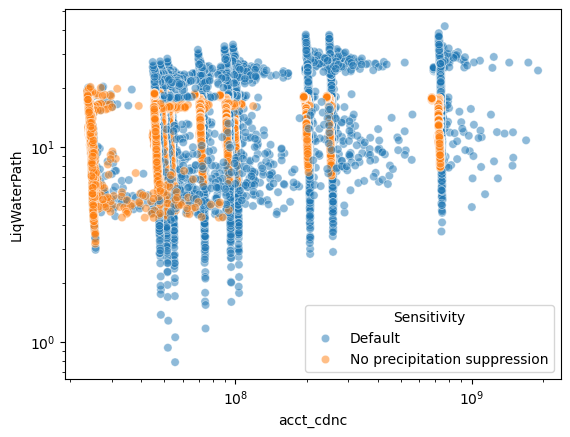

In [83]:
sns.scatterplot(data=big_df_ri, y="LiqWaterPath", x="acct_cdnc", hue="Sensitivity", alpha=0.5); plt.xscale("log"); plt.yscale("log")

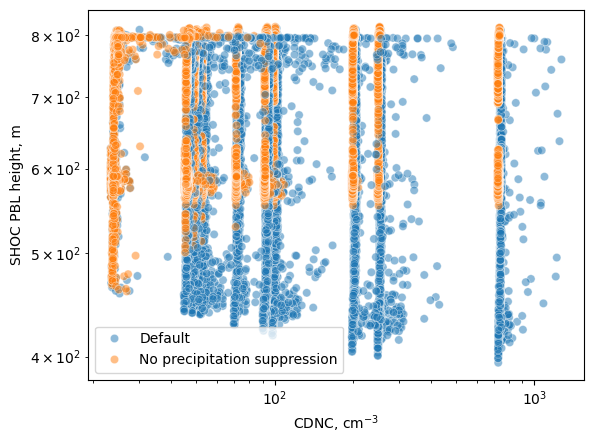

In [21]:
sns.scatterplot(data=big_df_ri, y="pbl_height", x="cdnc_at_cldtop", hue="Sensitivity", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(f"CDNC, cm$^{{-3}}$")
plt.ylabel("SHOC PBL height, m")
plt.legend(loc="lower left")
plt.savefig("../../aerosol-pert-mania/pbl_height_cdnc.png", dpi=300, bbox_inches="tight")

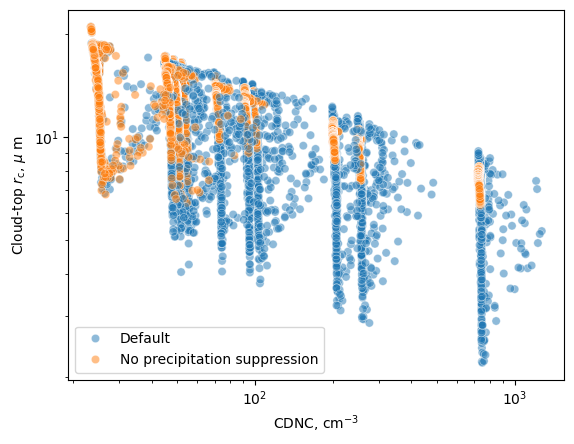

In [27]:
sns.scatterplot(data=big_df_ri, y="eff_radius_qc_at_cldtop", x="cdnc_at_cldtop", hue="Sensitivity", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(f"CDNC, cm$^{{-3}}$")
plt.ylabel(r"Cloud-top $r_\text{c}$, $\mu$ m")
plt.legend(loc="lower left")
plt.savefig("../../aerosol-pert-mania/eff_radius_cdnc.png", dpi=300, bbox_inches="tight")

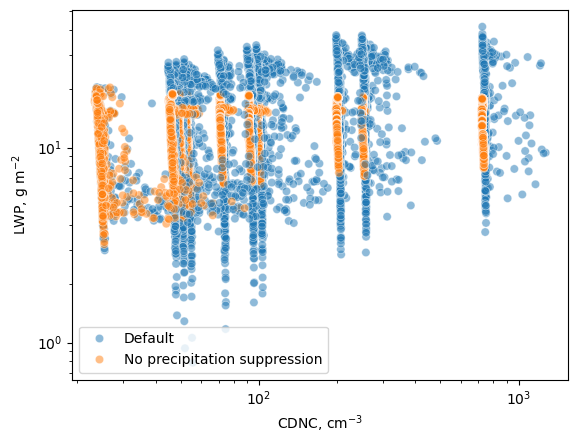

In [23]:
sns.scatterplot(data=big_df_ri, y="LiqWaterPath", x="cdnc_at_cldtop", hue="Sensitivity", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(f"CDNC, cm$^{{-3}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
plt.legend(loc="lower left")
plt.savefig("../../aerosol-pert-mania/lwp_cdnc.png", dpi=300, bbox_inches="tight")

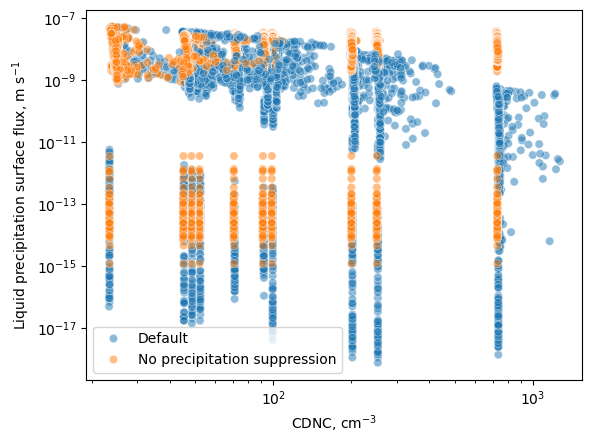

In [84]:
sns.scatterplot(data=big_df_ri, y="precip_liq_surf_mass_flux", x="cdnc_at_cldtop", hue="Sensitivity", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(f"CDNC, cm$^{{-3}}$")
plt.ylabel(f"Liquid precipitation surface flux, m s$^{{-1}}$")
plt.legend(loc="lower left")
plt.savefig("../../aerosol-pert-mania/precip_cdnc.png", dpi=300, bbox_inches="tight")

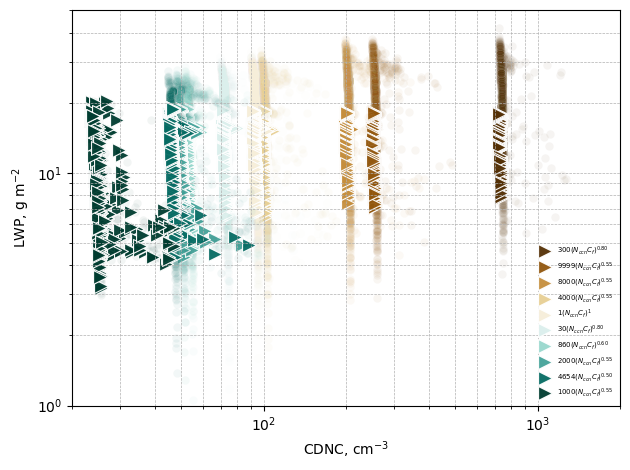

In [27]:
for exp in exps:
    df1 = dfs[exp]
    df2 = dfs[exp[:-4]]
    # change color for each experiment
    colors = plt.cm.BrBG(np.linspace(0, 1, len(exps)))
    color = colors[exps.index(exp)]
    a, b = exp.split("_")[3:5]
    a = a.replace("a", "")
    b = b.replace("p", "0.")
    sns.scatterplot(data=df2, x="cdnc_at_cldtop", y="LiqWaterPath", alpha=0.05, marker='o', color=color)
    sns.scatterplot(data=df1, x="cdnc_at_cldtop", y="LiqWaterPath", alpha=0.95, marker='>', color=color, label=f"${a} (N_{{ccn}} C_{{f}})^{{{b}}}$", s=100)
    # Set xscale and yscale to log
    plt.xscale("log"); plt.xlim(2e1, 2e3)
    plt.yscale("log"); plt.ylim(1e0, 5e1)
    plt.xlabel(f"CDNC, cm$^{{-3}}$")
    plt.ylabel(f"LWP, g m$^{{-2}}$")
    # make the grid at every minor tick
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.legend(bbox_to_anchor=(1.05, 0.80), loc='upper left', fontsize=10)
# remove the legend
plt.legend(loc='lower right', fontsize=5, frameon=False)
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp-cdnc-0ps-jmu.png", dpi=300, bbox_inches='tight')

In [55]:
some_df = pd.DataFrame()

some_df["cdnc"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=4).values.flatten() / 1e6
some_df["lwp"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].LiqWaterPath.values.flatten() * 100
some_df["lcc"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=3).values.flatten()

some_df["lcc0"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].cldfrac_liq_at_cldtop.values.flatten()
some_df["cdnc0"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].cdnc_at_cldtop.values.flatten() / 1e6
some_df["lwp0"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].LiqWaterPath.values.flatten() * 100

some_df["lwp0"] /= some_df["lcc0"]
some_df["cdnc0"] /= some_df["lcc0"]
some_df["lwp"] /= some_df["lcc"]
some_df["cdnc"] /= some_df["lcc"]

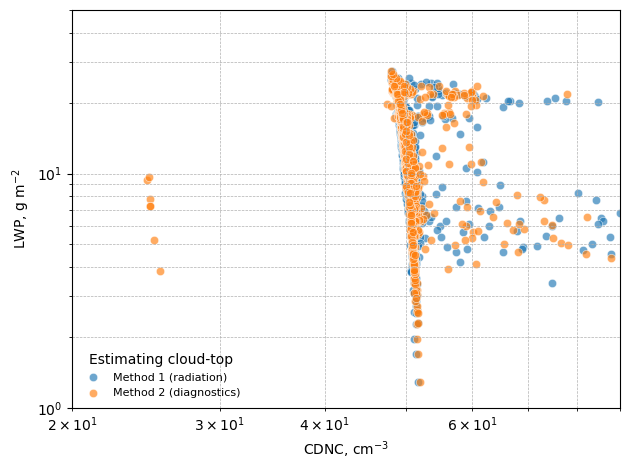

In [103]:
sns.scatterplot(data=some_df, x="cdnc0", y="lwp0", alpha=0.65, label=f"Method 1 (radiation)")
sns.scatterplot(data=some_df, x="cdnc", y="lwp", alpha=0.65, label=f"Method 2 (diagnostics)")
# Set xscale and yscale to log
plt.xscale("log"); plt.xlim(2e1, 9e1)
plt.yscale("log"); plt.ylim(1e0, 5e1)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
plt.xlabel(f"CDNC, cm$^{{-3}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
# plt.xscale("log"); plt.xlim(1e6, 1e8)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False, title="Estimating cloud-top")
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp-cdnc_methods.png", dpi=300, bbox_inches='tight')

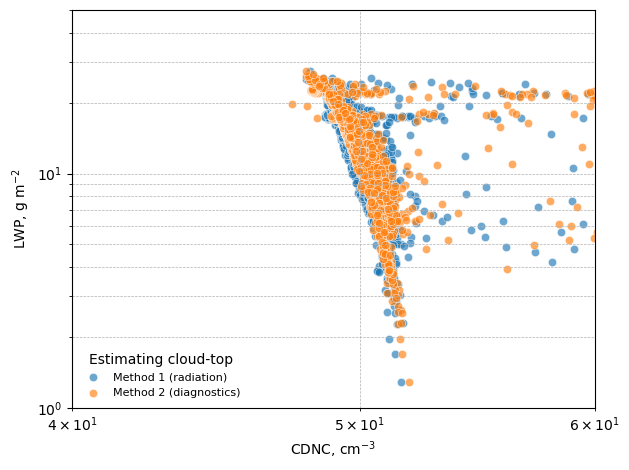

In [102]:
sns.scatterplot(data=some_df, x="cdnc0", y="lwp0", alpha=0.65, label=f"Method 1 (radiation)")
sns.scatterplot(data=some_df, x="cdnc", y="lwp", alpha=0.65, label=f"Method 2 (diagnostics)")
# Set xscale and yscale to log
plt.xscale("log"); plt.xlim(4e1, 6e1)
plt.yscale("log"); plt.ylim(1e0, 5e1)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
plt.xlabel(f"CDNC, cm$^{{-3}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
# plt.xscale("log"); plt.xlim(1e6, 1e8)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False, title="Estimating cloud-top")
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp-cdnc_methods_zoom.png", dpi=300, bbox_inches='tight')

In [106]:
some_df["nc_top"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=8).values.flatten()/data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=3).values.flatten()
some_df["nc_bot"] = data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldBot.isel(dim10=8).values.flatten()/data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop.isel(dim10=3).values.flatten()

/tmp/ipykernel_1957404/1024550111.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower left', fontsize=8, frameon=False)


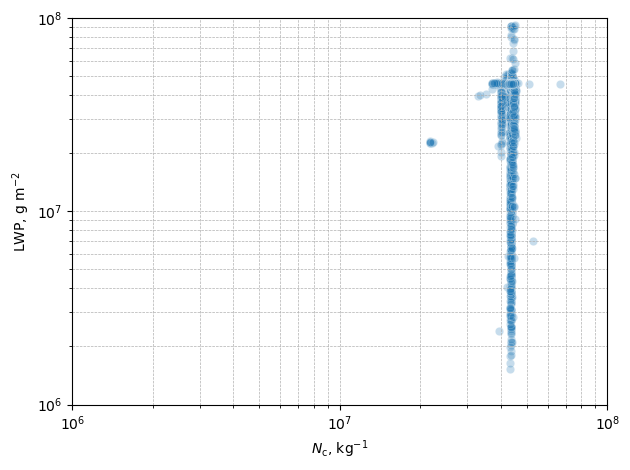

In [107]:
sns.scatterplot(data=some_df, x="nc_top", y="nc_bot", alpha=0.25)
# sns.scatterplot(data=some_df, x="nc_bot", y="lwp", alpha=0.25, label=f"nc_bot-lwp")
plt.xscale("log"); plt.xlim(1e6, 1e8)
plt.yscale("log"); plt.ylim(1e6, 1e8)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
plt.xlabel(f"$N_\\text{{c}}$, kg$^{{-1}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
# plt.xscale("log"); plt.xlim(1e6, 1e8)
# plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False)
plt.tight_layout()

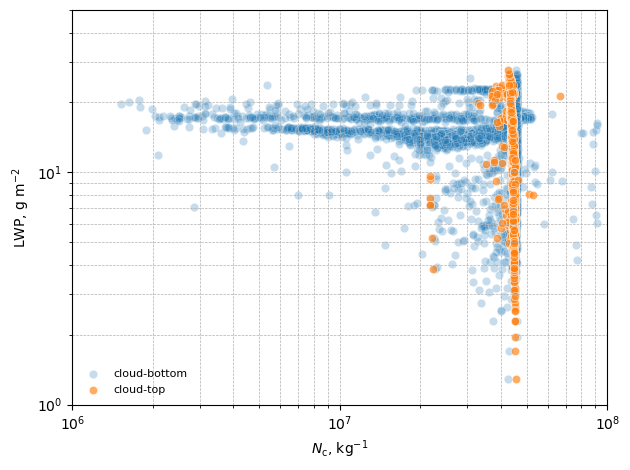

In [108]:
sns.scatterplot(data=some_df, x="nc_bot", y="lwp", alpha=0.25, label=f"cloud-bottom")
sns.scatterplot(data=some_df, x="nc_top", y="lwp", alpha=0.65, label=f"cloud-top")
# sns.scatterplot(data=some_df, x="cdnc0", y="lwp0", alpha=0.65, label=f"cdnc0-lwp0")
# Set xscale and yscale to log
plt.xlabel(f"$N_\\text{{c}}$, kg$^{{-1}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
plt.xscale("log"); plt.xlim(1e6, 1e8)
plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp_nc_topbot.png", dpi=300, bbox_inches='tight')


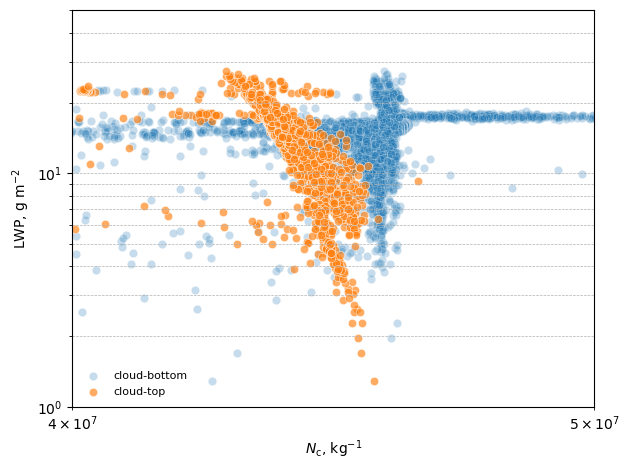

In [109]:
sns.scatterplot(data=some_df, x="nc_bot", y="lwp", alpha=0.25, label=f"cloud-bottom")
sns.scatterplot(data=some_df, x="nc_top", y="lwp", alpha=0.65, label=f"cloud-top")
# sns.scatterplot(data=some_df, x="cdnc0", y="lwp0", alpha=0.65, label=f"cdnc0-lwp0")
# Set xscale and yscale to log
plt.xlabel(f"$N_\\text{{c}}$, kg$^{{-1}}$")
plt.ylabel(f"LWP, g m$^{{-2}}$")
plt.xscale("log"); plt.xlim(4e7, 5e7)
plt.yscale("log"); plt.ylim(1e0, 5e1)
# make the grid at every minor tick
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower left', fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp_nc_topbot_zoom.png", dpi=300, bbox_inches='tight')

In [97]:
data["scream_dpxx_DYCOMSrf01_a2000_p55"].AeroComCldTop

<xarray.DataArray 'AeroComCldTop' (time: 73, ncol: 100, dim10: 10)> Size: 292kB
dask.array<open_dataset-AeroComCldTop, shape=(73, 100, 10), dtype=float32, chunksize=(73, 100, 10), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 584B 1999-07-11 ... 1999-07-11T06:00:00
Dimensions without coordinates: ncol, dim10
Attributes: (12/13)
    units:          1
    T_mid:          0 (K)
    cdnc:           4 (#/m3)
    cldfrac_ice:    2 (nondim)
    cldfrac_liq:    3 (nondim)
    cldfrac_tot:    7 (nondim)
    ...             ...
    eff_radius_qi:  6 (micron)
    nc:             8 (1/kg)
    ni:             9 (1/kg)
    p_mid:          1 (Pa)
    long_name:      MISSING
    standard_name:  MISSING

scream_dpxx_DYCOMSrf01_a2000_p55
scream_dpxx_DYCOMSrf01_a2000_p55_0ps


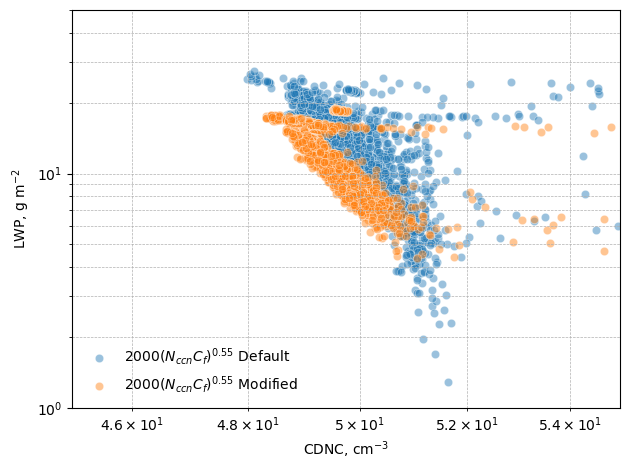

In [123]:
to_plot = ["scream_dpxx_DYCOMSrf01_a2000_p55", "scream_dpxx_DYCOMSrf01_a2000_p55_0ps"]
for exp in to_plot:
    print(exp)
    df = dfs[exp]
    # change color for each experiment
    # colors = plt.cm.BrBG(np.linspace(0, 1, len(to_plot)))
    # color = colors[to_plot.index(exp)]
    a, b = exp.split("_")[3:5]
    a = a.replace("a", "")
    b = b.replace("p", "0.")
    c = "Modified" if exp.endswith("0ps") else "Default"
    sns.scatterplot(data=df, x="cdnc_at_cldtop", y="LiqWaterPath", alpha=0.45, label=f"${a} (N_{{ccn}} C_{{f}})^{{{b}}}$ {c}")
    # Set xscale and yscale to log
    plt.xscale("log"); plt.xlim(4.5e1, 5.5e1)
    plt.yscale("log"); plt.ylim(1e0, 5e1)
    plt.xlabel(f"CDNC, cm$^{{-3}}$")
    plt.ylabel(f"LWP, g m$^{{-2}}$")
    # make the grid at every minor tick
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.legend(bbox_to_anchor=(1.05, 0.80), loc='upper left', fontsize=10)
# remove the legend
plt.legend(loc='lower left', fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig(f"../../aerosol-pert-mania/lwp-cdnc_0ps.png", dpi=300, bbox_inches='tight')

In [126]:
data["scream_dpxx_DYCOMSrf01_a2000_p55"].nc.mean().values, data["scream_dpxx_DYCOMSrf01_a2000_p55_0ps"].nc.mean().values

(array(3380149.8, dtype=float32), array(3132608., dtype=float32))